- do topic analysis.
    - create clusters
    - the most popular keywords for each cluster
    - cluster analysis
    - cluster sentiment analysis
- do citations analysis with topics
- do citation analysis: done
    - the most citated jounal and author
    - the most citated topics
- do keyword analysis (top keyword, their lifespan)
- analyze what topics have been discussed in the year of coronvisrs



checked data and final data

In [1]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('max_colwidth', 1000)

<h1>Basic Analysis</h1>

In [3]:
import pandas as pd

df = pd.read_csv("../data/topics_lon/checked_data.csv")
tp = pd.read_csv("../data/topics_lon/final_topics.csv")

In [4]:
df.columns

Index(['id', 'doi', 'title', 'pubYear', 'abstractText', 'source',
       'authorString', 'citedByCount', 'server', 'text', 'topic',
       'is_relevant', 'pmid'],
      dtype='object')

In [5]:
tp

,Topic,Count,Name,Representation,Representative_Docs,is_relevant
0,-1,406,-1_aging_lifespan_protein_cell,"['aging', 'lifespan', 'protein', 'cell', 'genes', 'mice', 'cells', 'model', 'stress', 'proteins']","['transcriptome analysis of the nematode <i>caenorhabditis elegans</i> and <i>litoditis marina</i> in a chemically defined food environment. diets regulate animal development, reproduction, and lifespan. however, the underlying molecular mechanisms remain elusive. a chemically defined cemm diet attenuates development and promotes longevity of c. elegans , but whether it impact on other nematodes is unknown. here, we studied the effect of the cemm diet on the development and longevity of the marine nematode litoditis marina , which belongs to the same family as c. elegans . we further investigated genome-wide transcriptional responses to cemm and op50 diet for both nematodes, respectively. we observed that the cemm diet attenuated l. marina development but did not extend its lifespan. we found that many of the foxo daf-16 target genes, lysosome and xenobiotic metabolism related genes were significantly increased on the cemm, which might contribute to the lifespan extension of c. ele...",True
1,0,317,0_brain_cognitive_adults_older,"['brain', 'cognitive', 'adults', 'older', 'healthy', 'memory', 'connectivity', 'older adults', 'functional', 'performance']","['resting-state eeg aperiodic exponent moderates the association between age and memory performance in older adults. memory functions are susceptible to age-related cognitive decline, making it essential to explore the underlying neurophysiological mechanisms that contribute to memory function during healthy ageing. resting-state eeg (rseeg) parameters, particularly the aperiodic exponent, a marker of cortical excitation-inhibition balance, and individual alpha frequency (iaf), a correlate of neural processing efficiency, have demonstrated associations with ageing and cognitive functions. this study investigated associations between these rseeg markers and performance across multiple memory systems in healthy older adults (n = 99) aged 50-84 years, specifically the moderating and mediating effects on memory and age-memory relationships across episodic, working, and visual short-term memory systems, assessed via computerised tasks. results revealed significant moderating effects of ...",True
2,1,86,1_biological_dnam_clocks_methylation,"['biological', 'dnam', 'clocks', 'methylation', 'epigenetic', 'biological age', 'aging', 'dna methylation', 'dna', 'clock']","['evaluation of epigenetic and metabolomic biomarkers indicating biological age. biological age captures a person’s age-related risk of unfavorable outcomes using biophysiological information. multivariate biological age measures include frailty scores and molecular biomarkers. these measures are often studied in isolation, but here we present a large-scale study comparing them. in two prospective cohorts ( n =3,196), we compared epigenetic (dnam horvath, dnam hannum, dnam phenoage, dnam grimage) and metabolomic-based (metaboage, metabohealth) biomarkers in reflection of biological age, as represented by five frailty measures and overall mortality. we observed that mortality-trained biological age markers, dnam grimage and metabohealth, outperformed age-trained biomarkers in frailty reflection and mortality prediction. the associations of dnam grimage and metabohealth with frailty and mortality were independent of each other and of the frailty score mimicking clinical geriatric ass...",True
3,2,85,2_genetic_variants_association_risk,"['genetic', 'variants', 'association', 'risk', 'diabetes', 'gwas', 'disease', 'mortality', 't2d', 'traits']","['robust inference and widespread genetic correlates from a large-scale genetic association study of human personality. personality traits describe stable differences in how individuals think, feel, and behave and how they interact with and experience their social and physical environ

In [4]:
df.shape

(2288, 13)

In [6]:
#Let's clean the dataset
df = df[df['is_relevant']==True]

In [7]:
df.shape

(1838, 13)

In [8]:
#Let's attach the topics to our dataset
tpp = tp[['Topic', 'Name', 'Representation']].rename(columns=
    {'Topic':'topic', 'Name':'topic_name', 'Representation':'topic_repr'})

df = df.merge(tpp, on = 'topic', how='left')

In [9]:
df.columns

Index(['id', 'doi', 'title', 'pubYear', 'abstractText', 'source',
       'authorString', 'citedByCount', 'server', 'text', 'topic',
       'is_relevant', 'pmid', 'topic_name', 'topic_repr'],
      dtype='object')

<h2>Number of articlea per year </h2>

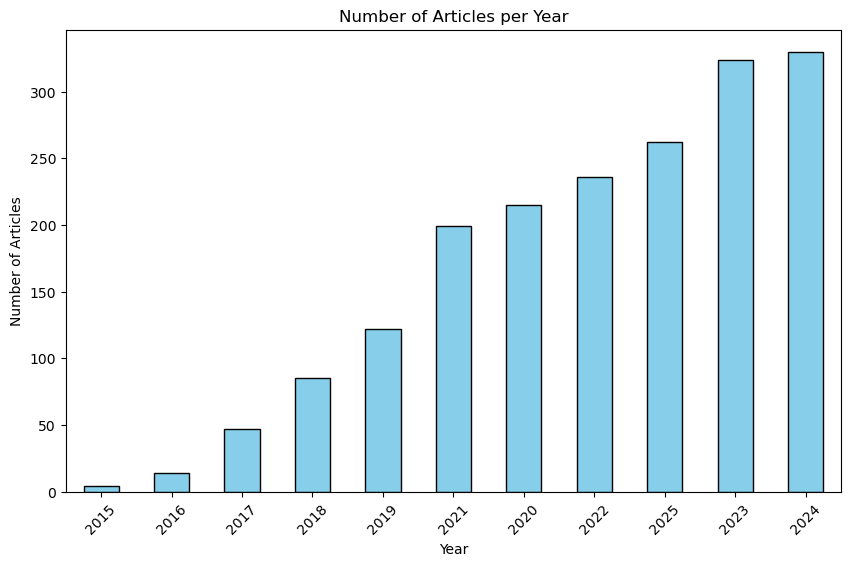

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure pubYear is numeric
df['pubYear'] = pd.to_numeric(df['pubYear'], errors='coerce')
yearly_counts = df['pubYear'].value_counts().sort_values()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
yearly_counts.plot(kind='bar', color="skyblue", edgecolor="black")
plt.title("Number of Articles per Year")
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

<h2> Topic analysis</h2>

<h3>Topic clustering</h3>

In [10]:
import pandas as pd
from bertopic import BERTopic

topic_model = BERTopic.load("../data/topics_lon/topic_model")

In [11]:
# Check if BERTopic has topic embeddings stored
if hasattr(topic_model, "topic_embeddings_") and topic_model.topic_embeddings_ is not None:
    print("topic_embeddings_ already available!")
    print("Shape:", topic_model.topic_embeddings_.shape)
else:
    print("No topic_embeddings_ found. Need to compute manually.")

topic_embeddings_ already available!
Shape: (67, 768)


In [12]:
import umap
import hdbscan
import numpy as np
import pandas as pd
from hdbscan.validity import validity_index as hdbscan_dbcv

# 1) Get topic embeddings (e.g., from BERTopic)
embeddings = np.array(topic_model.topic_embeddings_)  # shape (n_topics, d)
n_topics = embeddings.shape[0]

# UMAP: more local neighborhoods
umap_model = umap.UMAP(
    n_neighbors=8,        # was 30
    n_components=5,       # a bit tighter
    min_dist=0.0,
    metric="cosine",
    random_state=42
)
reduced = umap_model.fit_transform(embeddings)

# HDBSCAN: smaller clusters + leaf selection + small min_samples
min_cluster_size = max(5, int(0.015 * n_topics))  # ~1.5% or at least 5

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=2,                     # smaller = more clusters
    metric="euclidean",
    cluster_selection_method="leaf",   # finer splits than "eom"
    prediction_data=True
)
labels = clusterer.fit_predict(reduced)

# 4) Attach to topic info (+ strengths)
topic_info = topic_model.get_topic_info().copy()
topic_info["topic_cluster"] = labels
topic_info["cluster_strength"] = getattr(clusterer, "probabilities_", np.ones_like(labels))

In [13]:
topic_info["topic_cluster"].nunique()

7

In [14]:
import pandas as pd

# topic_info already has topic_id and topic_cluster
# add top words for each topic
topic_info["top_words"] = topic_info["Topic"].apply(
    lambda t: " ".join([w for w, _ in topic_model.get_topic(t)[:10]])
)

# summarize per cluster
cluster_labels = (
    topic_info.groupby("topic_cluster")["top_words"]
    .apply(lambda texts: " ".join(texts).split())   # all words across topics
    .apply(lambda words: pd.Series(words).value_counts().head(4).index.tolist())  # top 4 words
    .apply(lambda words: " / ".join(words))
    .reset_index()
    .rename(columns={"top_words": "meta_topic_name"})
)

print(cluster_labels)

   topic_cluster                              meta_topic_name
0             -1       aging / dna / methylation / epigenetic
1              0                      sars / cov / 19 / covid
2              1              life / physical / 19 / activity
3              2  drosophila / melanogaster / flies / insects
4              3             history / plant / life / species
5              4              mice / male / ageing / lifespan
6              5            elegans / lifespan / stress / daf


In [15]:
topic_info.groupby('topic_cluster')['Count'].sum()

topic_cluster
-1    1352
 0     107
 1      98
 2     177
 3     155
 4      97
 5     302
Name: Count, dtype: int64

In [16]:
from collections import Counter, defaultdict
import pandas as pd

def cluster_top_words(topic_model, topic_info, topn=10, exclude_noise=False, extra_stopwords=None):
    """
    Aggregate BERTopic topic words into cluster-level top words by summing weights.
    Returns a DataFrame with cluster id, top words, and a suggested meta name.
    """
    topics_dict = topic_model.get_topics()  # {topic_id: [(word, weight), ...]}
    if extra_stopwords is None:
        extra_stopwords = set()

    # Map cluster -> topic IDs
    df = topic_info[['Topic', 'topic_cluster']].dropna().copy()
    if exclude_noise:
        df = df[df['topic_cluster'] != -1]

    clusters = defaultdict(list)
    for _, row in df.iterrows():
        clusters[row['topic_cluster']].append(int(row['Topic']))

    rows = []
    for cluster_id, topic_ids in sorted(clusters.items(), key=lambda x: x[0]):
        agg = Counter()
        for tid in topic_ids:
            if tid in topics_dict:
                for w, wgt in topics_dict[tid]:
                    if (not w) or (w in extra_stopwords):
                        continue
                    agg[w] += float(wgt)  # sum weights across topics in this cluster

        if not agg:
            top_words = []
        else:
            # take top-n words
            top_words = [w for w, _ in agg.most_common(topn)]

        # make a short human label from the first 4–6 words
        k_for_label = min(6, max(3, topn // 2))
        meta_name = " / ".join(top_words[:k_for_label])

        rows.append({
            "topic_cluster": cluster_id,
            "n_topics_in_cluster": len(topic_ids),
            "top_words": top_words,
            "meta_topic_name": meta_name
        })

    out = pd.DataFrame(rows).sort_values("topic_cluster").reset_index(drop=True)
    return out

# ---- use it ----
EXTRA_STOPS = {"method", "methods", "introduction", "background", "result", "results",
               "conclusion", "conclusions", "study", "paper", "biorxiv", "medrxiv",
               "preprint", "copyright", "license"}

cluster_labels = cluster_top_words(topic_model, topic_info, topn=12, extra_stopwords=EXTRA_STOPS)
print(cluster_labels[["topic_cluster", "meta_topic_name", "top_words"]])


   topic_cluster  \
0             -1   
1              0   
2              1   
3              2   
4              3   
5              4   
6              5   

                                                             meta_topic_name  \
0                       epigenetic / methylation / bat / bats / skin / aging   
1                              sars / sars cov / cov / 19 / antibody / covid   
2  childhood / physical activity / physical / purpose / mortality / pandemic   
3              wolbachia / mosquitoes / host / drosophila / mosquito / flies   
4                             plant / seed / species / sperm / plants / soil   
5         rapamycin / mice / reprogramming / rejuvenation / treatment / mtor   
6                    elegans / mitochondrial / daf / lifespan / mir / muscle   

                                                                                                                       top_words  
0                                   [epigenetic, methylation, bat, 

In [17]:
cluster_labels[["topic_cluster", "meta_topic_name", "top_words"]]

,topic_cluster,meta_topic_name,top_words
0,-1,epigenetic / methylation / bat / bats / skin / aging,"[epigenetic, methylation, bat, bats, skin, aging, tdp 43, 43, tdp, gut, dna methylation, ad]"
1,0,sars / sars cov / cov / 19 / antibody / covid,"[sars, sars cov, cov, 19, antibody, covid, covid 19, vaccine, responses, antibodies, malaria, igg]"
2,1,childhood / physical activity / physical / purpose / mortality / pandemic,"[childhood, physical activity, physical, purpose, mortality, pandemic, life purpose, income, countries, covid, care, frailty]"
3,2,wolbachia / mosquitoes / host / drosophila / mosquito / flies,"[wolbachia, mosquitoes, host, drosophila, mosquito, flies, insects, larvae, hosts, insect, queens, queen]"
4,3,plant / seed / species / sperm / plants / soil,"[plant, seed, species, sperm, plants, soil, telomere, root, autophagy, growth, telomere length, offspring]"
5,4,rapamycin / mice / reprogramming / rejuvenation / treatment / mtor,"[rapamycin, mice, reprogramming, rejuvenation, treatment, mtor, senescence, lifespan, male, drugs, aging, ageing]"
6,5,elegans / mitochondrial / daf / lifespan / mir / muscle,"[elegans, mitochondrial, daf, lifespan, mir, muscle, mtdna, 16, daf 16, mirnas, sirt3, sirt6]"


In [19]:
tpp  = topic_info[['Topic', 'topic_cluster']].rename(columns = {'Topic':'topic'})

df = df.merge(
    tpp,
    on='topic',
    how="left"
)

In [20]:
#Let's give the clusters meaningful name
rename_map = {
    -1: "Epigenetics & Neurodegeneration in Aging",
    0: "COVID-19 & Immune Response",
    1: "Lifestyle, Psychosocial Factors & Healthy Aging",
    2: "Insect Models & Vector Biology",
    3: "Plant Biology & Cellular Aging Mechanisms",
    4: "Longevity Interventions & Rejuvenation",
    5: "C. elegans & Molecular Aging Pathways"
}

df["meta_topic_name"] = df["topic_cluster"].map(rename_map)

In [21]:
df.groupby('meta_topic_name').size()

meta_topic_name
C. elegans & Molecular Aging Pathways               290
COVID-19 & Immune Response                           34
Epigenetics & Neurodegeneration in Aging           1217
Insect Models & Vector Biology                       92
Lifestyle, Psychosocial Factors & Healthy Aging      98
Longevity Interventions & Rejuvenation               97
Plant Biology & Cellular Aging Mechanisms            10
dtype: int64

In [23]:
df.columns

Index(['id', 'doi', 'title', 'pubYear', 'abstractText', 'source',
       'authorString', 'citedByCount', 'server', 'text', 'topic',
       'is_relevant', 'pmid', 'topic_name', 'topic_repr', 'topic_cluster',
       'meta_topic_name'],
      dtype='object')

In [39]:
df.to_csv("../data/topics_lon/analyzed_data.csv", index=False)

<h3> How many preprints per cluster per year</h3>

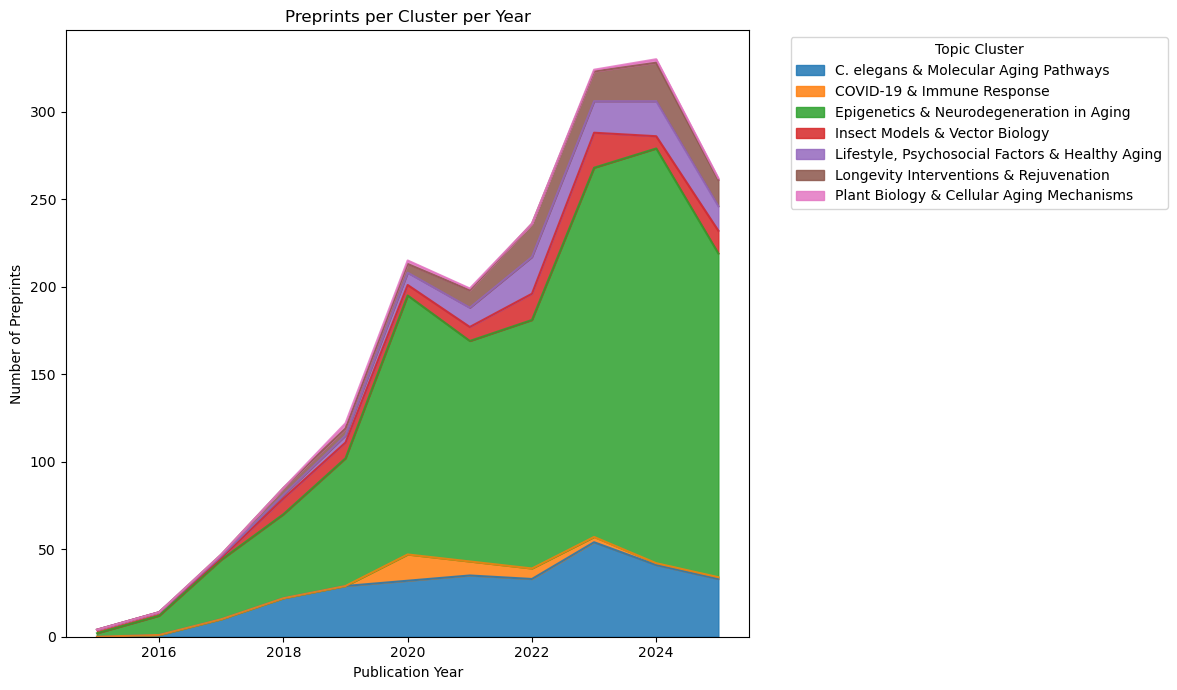

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1) Make sure columns are clean ---
df['pubYear'] = pd.to_numeric(df['pubYear'], errors='coerce')
df['topic_cluster'] = df['topic_cluster'].fillna(-1).astype(int)

# --- 2) Count preprints per cluster per year ---
topic_counts = (
    df.groupby(['pubYear','topic_cluster'])
      .size()
      .reset_index(name='count')
)

# Optional: attach meta topic names if available
if 'meta_topic_name' in df.columns:
    mapping = df[['topic_cluster','meta_topic_name']].drop_duplicates()
    topic_counts = topic_counts.merge(mapping, on='topic_cluster', how='left')
else:
    topic_counts['meta_topic_name'] = topic_counts['topic_cluster'].astype(str)

# --- 3) Pivot for plotting (year × cluster matrix) ---
topic_matrix = topic_counts.pivot(
    index='pubYear',
    columns='meta_topic_name',
    values='count'
).fillna(0)

# --- 4) Plot as stacked area chart ---
plt.figure(figsize=(12,7))
topic_matrix.plot.area(ax=plt.gca(), alpha=0.85)
plt.title("Preprints per Cluster per Year")
plt.xlabel("Publication Year")
plt.ylabel("Number of Preprints")
plt.legend(title="Topic Cluster", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


<h3>Average abstract sentiment by clusters</h3>

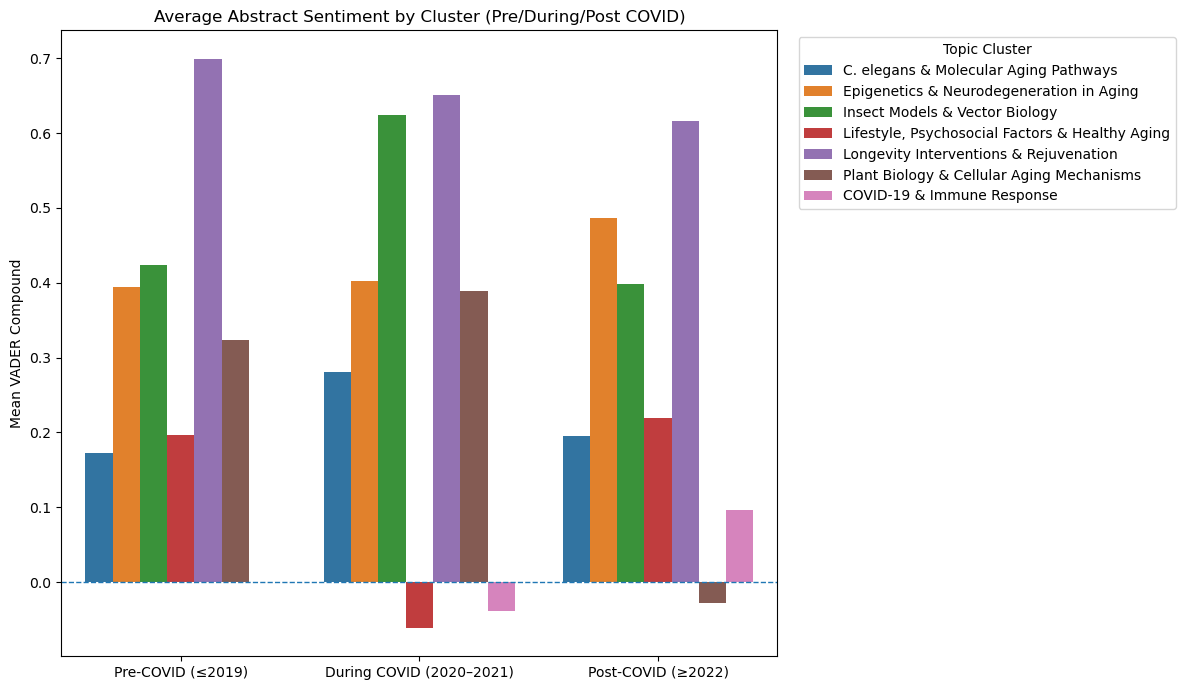

In [30]:
if 'sentiment' not in df.columns:
    import nltk
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    sid = SentimentIntensityAnalyzer()
    df['abstractText'] = df['abstractText'].fillna("").astype(str)
    df['sentiment'] = df['abstractText'].apply(lambda t: sid.polarity_scores(t)['compound'])

sent = (df.dropna(subset=['period'])
          .groupby(['period','cluster_label'])['sentiment']
          .mean()
          .reset_index())

sent['period'] = pd.Categorical(sent['period'], categories=period_order, ordered=True)
sent = sent.sort_values(['period','cluster_label'])

plt.figure(figsize=(12,7))
sns.barplot(data=sent, x='period', y='sentiment', hue='cluster_label')
plt.axhline(0, linestyle='--', linewidth=1)
plt.title("Average Abstract Sentiment by Cluster (Pre/During/Post COVID)")
plt.xlabel("")
plt.ylabel("Mean VADER Compound")
plt.legend(title="Topic Cluster", bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


<h3> Topics over time</h3>

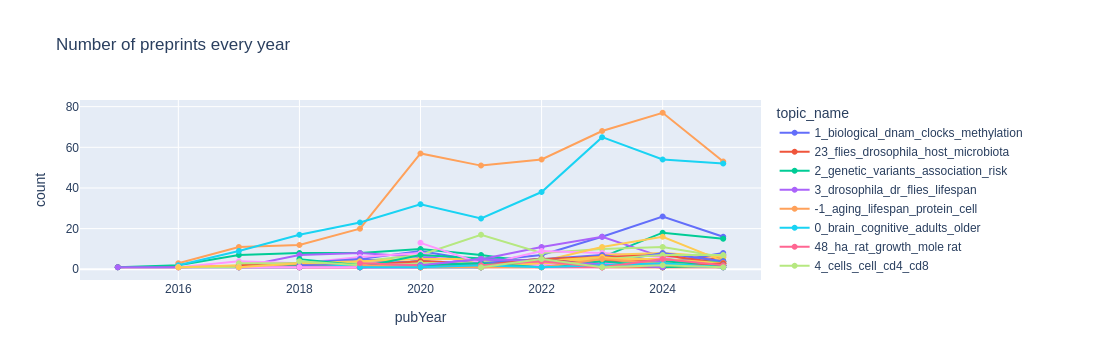

In [32]:
topic_counts = (
    df
    .groupby(['pubYear', 'topic_name'])
    .size()
    .reset_index(name='count')
)

import plotly.express as px

fig = px.line(
    topic_counts,
    x="pubYear", y="count", color="topic_name",
    markers=True,
    title="Number of preprints every year"
)
fig.show()


<h2>Citations dyanmics over time</h2>

<h3>Average Citations per Article over Time</h3>

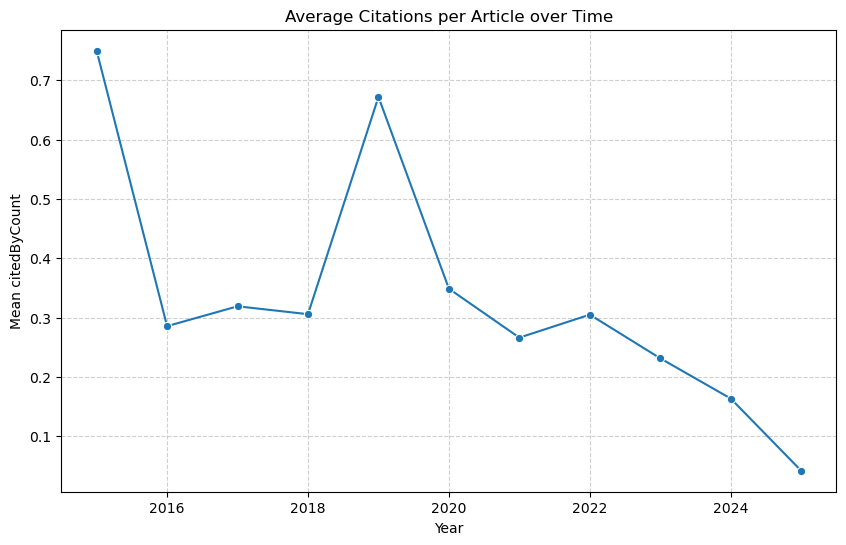

In [34]:
import seaborn as sns

# Average citations per year
yearly_citations = (
    df.groupby("pubYear")["citedByCount"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.lineplot(data=yearly_citations, x="pubYear", y="citedByCount", marker="o")
plt.title("Average Citations per Article over Time")
plt.ylabel("Mean citedByCount")
plt.xlabel("Year")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

<h3>Top cited articles (top 5)</h3>

Top 5 most cited preprints:
                                                  title  citedByCount  \
1788  OASIS-3: Longitudinal Neuroimaging, Clinical, ...            52   
1817  SARS-CoV-2 infection induces robust, neutraliz...            26   
1316  Universal DNA methylation age across mammalian...            13   
182   <i>ClockBase</i>: a comprehensive platform for...             7   
1447  Why not record from <i>every</i> electrode wit...             7   

                              doi  
1788  10.1101/2019.12.13.19014902  
1817  10.1101/2020.07.14.20151126  
1316    10.1101/2021.01.18.426733  
182     10.1101/2023.02.28.530532  
1447               10.1101/275818  


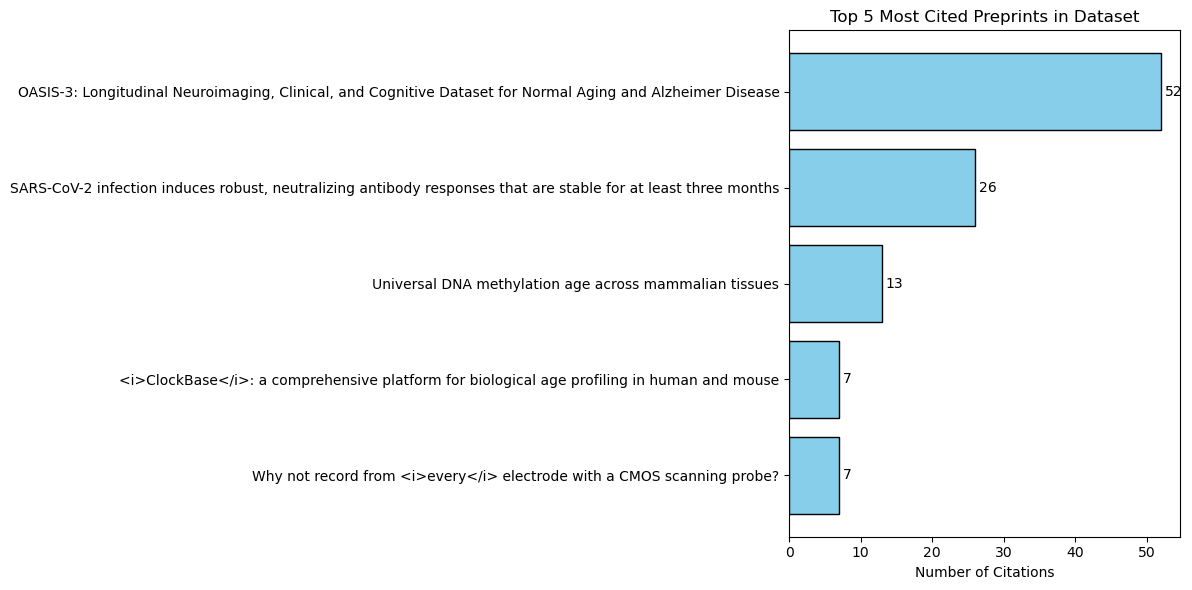

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Ensure citations are numeric ---
df['citedByCount'] = pd.to_numeric(df['citedByCount'], errors='coerce').fillna(0)

# --- 2. Pick top 5 by citation count ---
top5 = df.nlargest(5, 'citedByCount')[['title', 'citedByCount', 'doi']]

print("Top 5 most cited preprints:")
print(top5)

# --- 3. Plot as bar chart ---
plt.figure(figsize=(12,6))
bars = plt.barh(
    top5['title'],
    top5['citedByCount'],
    color="skyblue",
    edgecolor="black"
)
plt.xlabel("Number of Citations")
plt.title("Top 5 Most Cited Preprints in Dataset")
plt.gca().invert_yaxis()  # highest at the top

# --- 4. Add citation labels to bars ---
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f"{int(width)}", va="center")

plt.tight_layout()
plt.show()


In [16]:
df.columns

Index(['id', 'doi', 'title', 'pubYear', 'abstractText', 'source',
       'authorString', 'citedByCount', 'server', 'text', 'topic',
       'is_relevant', 'pmid', 'topic_name_x', 'topic_repr_x', 'topic_name_y',
       'topic_repr_y'],
      dtype='object')

<h3>Sentiment analysis of the top 5 topics over time </h3>

Top 5 most cited preprints with sentiment:
                                                                                                         title                         doi  citedByCount  sent_compound  sent_pos  sent_neu  sent_neg sent_label
    OASIS-3: Longitudinal Neuroimaging, Clinical, and Cognitive Dataset for Normal Aging and Alzheimer Disease 10.1101/2019.12.13.19014902            52         0.6486     0.034     0.966     0.000   positive
SARS-CoV-2 infection induces robust, neutralizing antibody responses that are stable for at least three months 10.1101/2020.07.14.20151126            26         0.2263     0.098     0.835     0.067   positive
                                                        Universal DNA methylation age across mammalian tissues   10.1101/2021.01.18.426733            13        -0.8474     0.037     0.893     0.070   negative
                    <i>ClockBase</i>: a comprehensive platform for biological age profiling in human and mouse   10.1101/

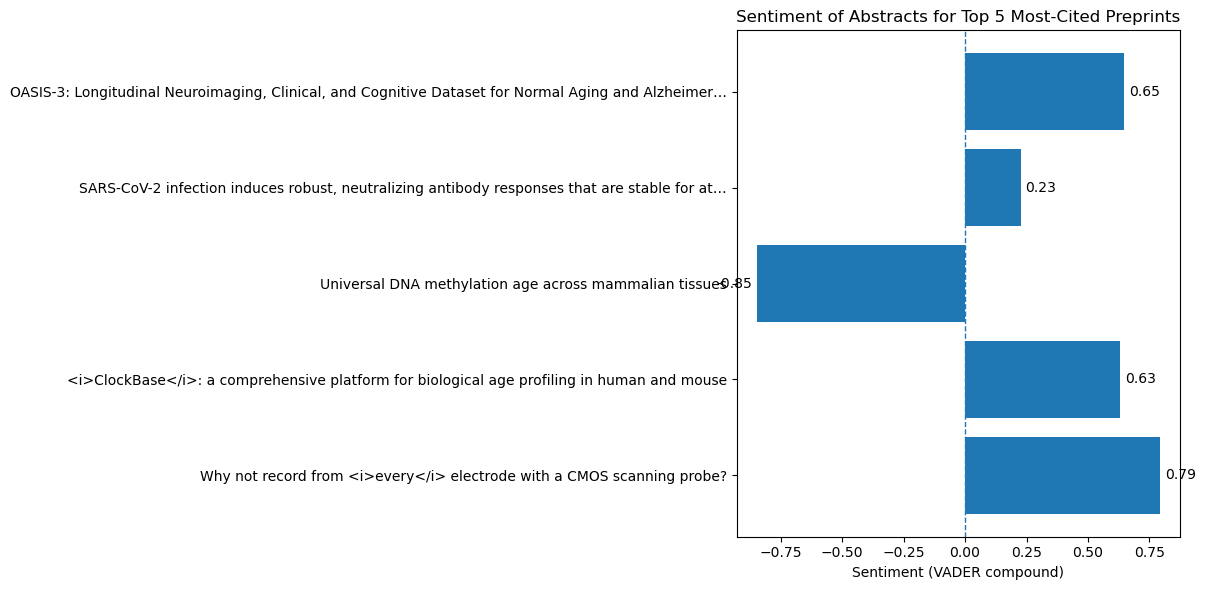

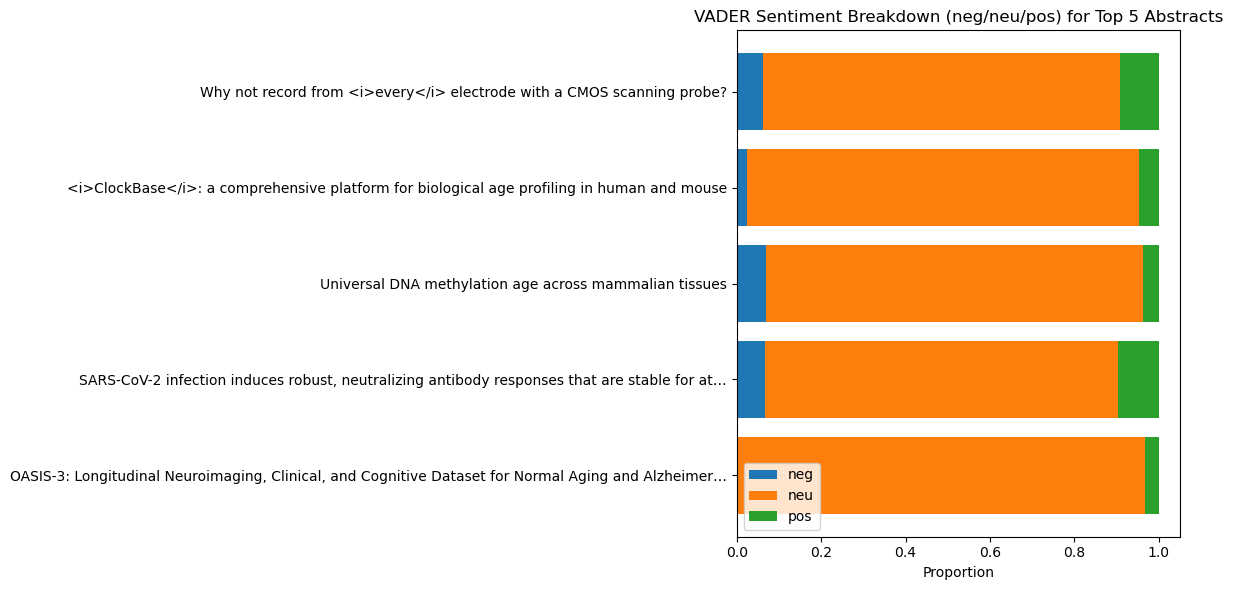

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer

top5 = df.nlargest(5, 'citedByCount')[['title', 'doi', 'abstractText', 'citedByCount']].copy()

sid = SentimentIntensityAnalyzer()

def sentiment_scores(text: str):
    # VADER expects reasonably shortish English; abstracts are fine.
    # If the abstract is empty, VADER returns compound ~ 0.0 (neutral).
    s = sid.polarity_scores(text or "")
    return pd.Series({
        'sent_compound': s['compound'],
        'sent_pos': s['pos'],
        'sent_neu': s['neu'],
        'sent_neg': s['neg']
    })

sent_cols = top5['abstractText'].apply(sentiment_scores)
top5 = pd.concat([top5.reset_index(drop=True), sent_cols.reset_index(drop=True)], axis=1)

# 4) Optional: label (positive/neutral/negative)
def label_sent(x):
    if x >= 0.05: return "positive"
    if x <= -0.05: return "negative"
    return "neutral"

top5['sent_label'] = top5['sent_compound'].apply(label_sent)

# 5) (Nice-to-have) shorten long titles for plotting
def shorten_title(t, max_words=12):
    words = t.split()
    return " ".join(words[:max_words]) + ("…" if len(words) > max_words else "")

top5['title_short'] = top5['title'].apply(shorten_title)

# 6) Show a table in the console
print("Top 5 most cited preprints with sentiment:")
display_cols = ['title', 'doi', 'citedByCount', 'sent_compound', 'sent_pos', 'sent_neu', 'sent_neg', 'sent_label']
print(top5[display_cols].to_string(index=False))

# 7) Plot: compound sentiment per article
plt.figure(figsize=(12, 6))
bars = plt.barh(top5['title_short'], top5['sent_compound'])
plt.axvline(0.0, linestyle='--', linewidth=1)
plt.xlabel("Sentiment (VADER compound)")
plt.title("Sentiment of Abstracts for Top 5 Most-Cited Preprints")
plt.gca().invert_yaxis()

# Add numeric labels
for bar in bars:
    w = bar.get_width()
    plt.text(
        x=w + (0.02 if w >= 0 else -0.02),
        y=bar.get_y() + bar.get_height()/2,
        s=f"{w:.2f}",
        va="center",
        ha="left" if w >= 0 else "right"
    )

plt.tight_layout()
plt.show()

# 8) (Optional) Stacked bar of pos/neu/neg proportions
fig = plt.figure(figsize=(12, 6))
y = np.arange(len(top5))
plt.barh(y, top5['sent_neg'], label='neg')
plt.barh(y, top5['sent_neu'], left=top5['sent_neg'], label='neu')
plt.barh(y, top5['sent_pos'], left=top5['sent_neg'] + top5['sent_neu'], label='pos')
plt.yticks(y, top5['title_short'])
plt.xlabel("Proportion")
plt.title("VADER Sentiment Breakdown (neg/neu/pos) for Top 5 Abstracts")
plt.legend()
plt.tight_layout()
plt.show()

<h2>TF-IDF analysis</h2>

            term      score
3573          h4  77.878218
545        aging  60.810748
451          age  52.509063
4639    lifespan  40.825993
4791   longevity  38.004799
1178       brain  34.310065
1385       cells  30.515272
874   associated  30.288508
1352        cell  28.719763
1618   cognitive  27.960557
6865     related  27.241312
3719      health  27.220087
7820       study  26.913697
3752     healthy  26.394417
521       ageing  26.007580
2081        data  25.909626
4625        life  25.362676
1457     changes  25.353727
3402       genes  24.091399
2409     disease  23.990293


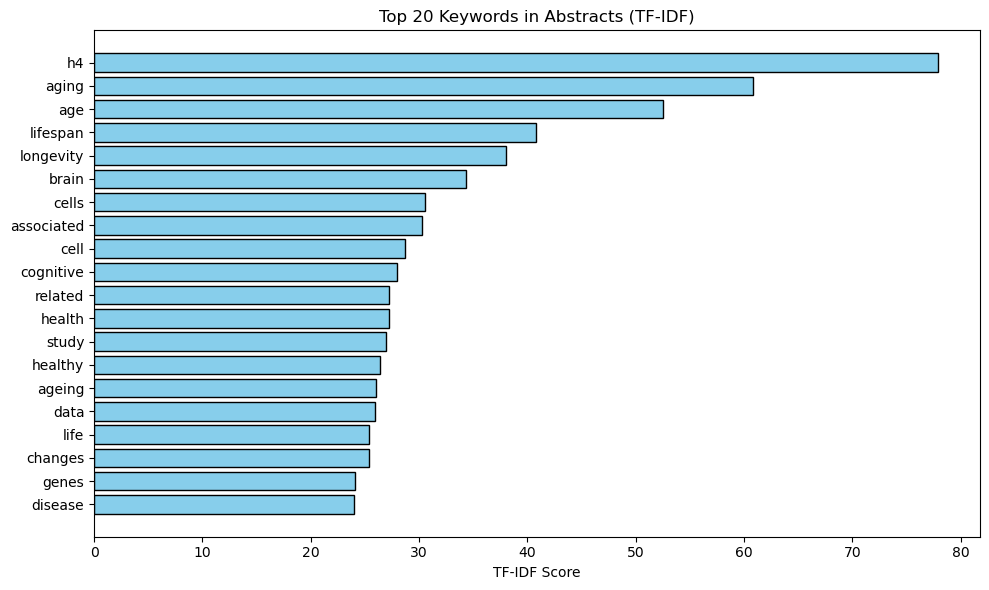

In [31]:
# --- TF-IDF on Abstracts: Global Top Keywords ---
# from nltk.corpus import stopwords
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# 1) Clean abstracts
df['abstractText'] = df['abstractText'].fillna("").astype(str)

def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r'https?://\S+|doi:\S+|10\.\d{4,9}/\S+', ' ', s)   # remove URLs / DOIs
    s = re.sub(r'[^a-z0-9\s]', ' ', s)                            # keep alphanumerics
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df['clean'] = df['abstractText'].apply(clean_text)

# custom_stopwords = list(stopwords.words("english")) + ["youtubeshorts", "shorts", "http", "https", "youtube",
#                                                        "video", "videos", "watch", "channel", "subscribe", "com"]
# 2) TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),       # unigrams + bigrams
    min_df=5,                # ignore very rare words
    max_df=0.85,             # ignore very common words
)

X = vectorizer.fit_transform(df['clean'])
terms = vectorizer.get_feature_names_out()

# 3) Compute global importance by summing TF-IDF scores across all docs
scores = X.sum(axis=0).A1
tfidf_df = pd.DataFrame({'term': terms, 'score': scores})
tfidf_df = tfidf_df.sort_values(by='score', ascending=False)

# 4) Top keywords
TOP_N = 20
top_terms = tfidf_df.head(TOP_N)
print(top_terms)

# 5) Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_terms['term'][::-1], top_terms['score'][::-1], color="skyblue", edgecolor="black")
plt.title(f"Top {TOP_N} Keywords in Abstracts (TF-IDF)")
plt.xlabel("TF-IDF Score")
plt.tight_layout()
plt.show()


<h3>Keywords over time</h3>

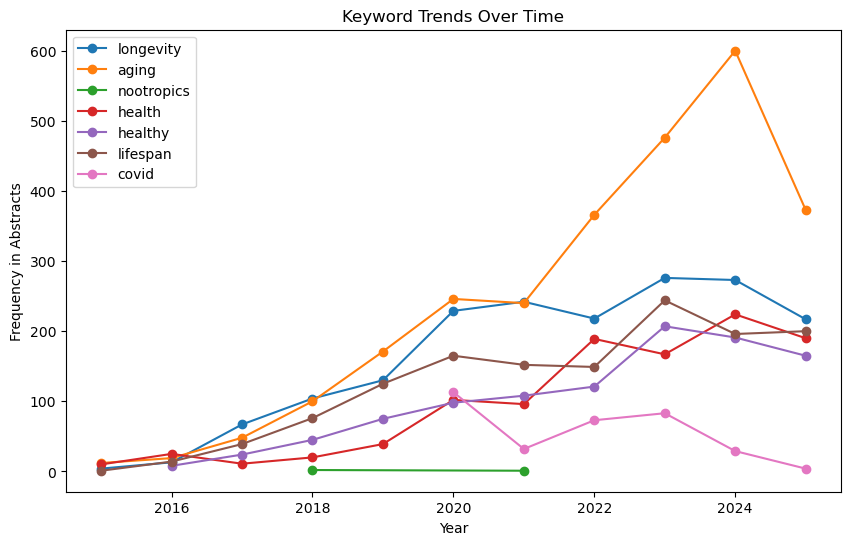

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# simple tokenizer
def tokenize(text):
    if not isinstance(text, str):
        return []
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())
    return words

# add a column with tokenized abstract
df['tokens'] = df['abstractText'].apply(tokenize)

# count keywords per year
year_keywords = (
    df.explode('tokens')
      .groupby(['pubYear','tokens'])
      .size()
      .reset_index(name='count')
)

# pick some focus w
focus = ['longevity', 'aging', 'nootropics', 'health', 'healthy', "lifespan", "covid"]

subset = year_keywords[year_keywords['tokens'].isin(focus)]

plt.figure(figsize=(10,6))
for word in focus:
    sub = subset[subset['tokens']==word]
    plt.plot(sub['pubYear'], sub['count'], marker="o", label=word)

plt.title("Keyword Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Frequency in Abstracts")
plt.legend()
plt.show()


<h3>WordClouds</h3>

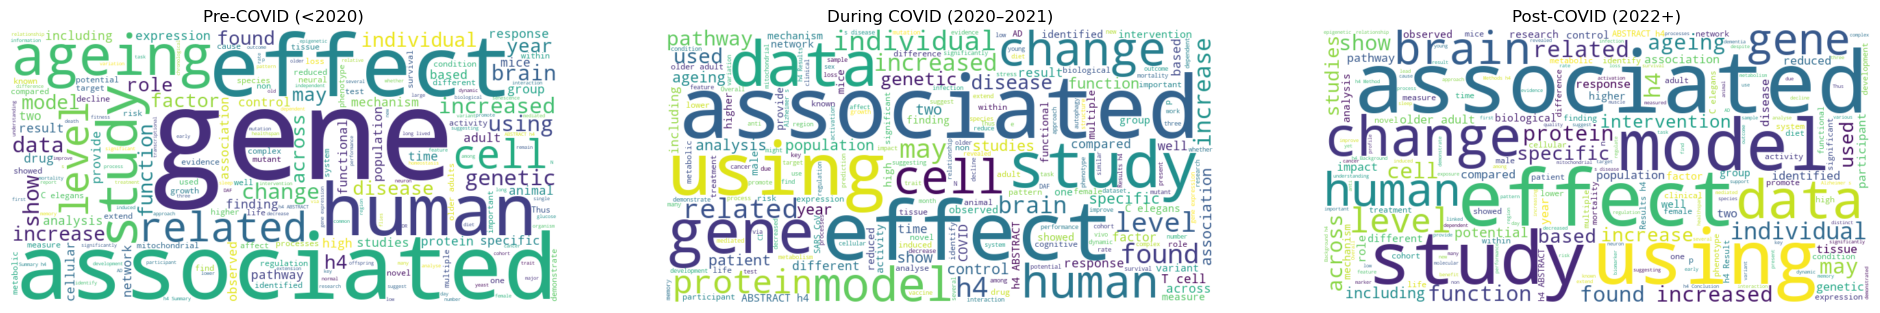

In [36]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1) Extend stopwords
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'longevity', 'aging', 'nootropics', 'health', 'healthy', "lifespan", "age"
])

# 2) Split abstracts into three groups
pre_text = " ".join(df[df['pubYear'] < 2020]['abstractText'].dropna())
during_text = " ".join(df[(df['pubYear'] >= 2020) & (df['pubYear'] <= 2021)]['abstractText'].dropna())
post_text = " ".join(df[df['pubYear'] >= 2022]['abstractText'].dropna())

# 3) Generate word clouds with custom stopwords
wordcloud_pre = WordCloud(width=800, height=400, stopwords=custom_stopwords,
                          background_color="white").generate(pre_text)
wordcloud_during = WordCloud(width=800, height=400, stopwords=custom_stopwords,
                             background_color="white").generate(during_text)
wordcloud_post = WordCloud(width=800, height=400, stopwords=custom_stopwords,
                           background_color="white").generate(post_text)

# 4) Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(24,8))

axes[0].imshow(wordcloud_pre, interpolation='bilinear')
axes[0].set_title("Pre-COVID (<2020)")
axes[0].axis("off")

axes[1].imshow(wordcloud_during, interpolation='bilinear')
axes[1].set_title("During COVID (2020–2021)")
axes[1].axis("off")

axes[2].imshow(wordcloud_post, interpolation='bilinear')
axes[2].set_title("Post-COVID (2022+)")
axes[2].axis("off")

plt.show()


In [37]:
df.columns

Index(['id', 'doi', 'title', 'pubYear', 'abstractText', 'source',
       'authorString', 'citedByCount', 'server', 'text', 'topic',
       'is_relevant', 'pmid', 'topic_name', 'topic_repr', 'topic_cluster',
       'meta_topic_name', 'period', 'cluster_label', 'sentiment', 'clean',
       'tokens'],
      dtype='object')

<h2>Sentiment analysis</h2>

<h3>Average sentiments of the abstracts</h3>

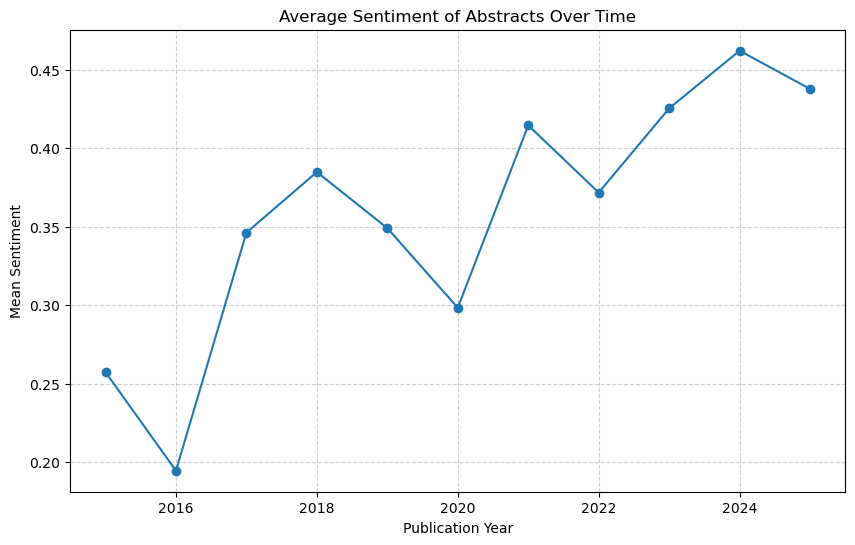

In [19]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd


sid = SentimentIntensityAnalyzer()

# Ensure we don’t crash on missing abstracts
df['abstractText'] = df['abstractText'].fillna("")

# Get polarity scores (compound ranges from -1 to +1)
df['sentiment'] = df['abstractText'].apply(lambda x: sid.polarity_scores(x)['compound'])


# Group by year
sentiment_trend = df.groupby('pubYear')['sentiment'].mean()

plt.figure(figsize=(10,6))
sentiment_trend.plot(marker="o")
plt.title("Average Sentiment of Abstracts Over Time")
plt.xlabel("Publication Year")
plt.ylabel("Mean Sentiment")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


<h3>Number of sentiments for each category</h3>

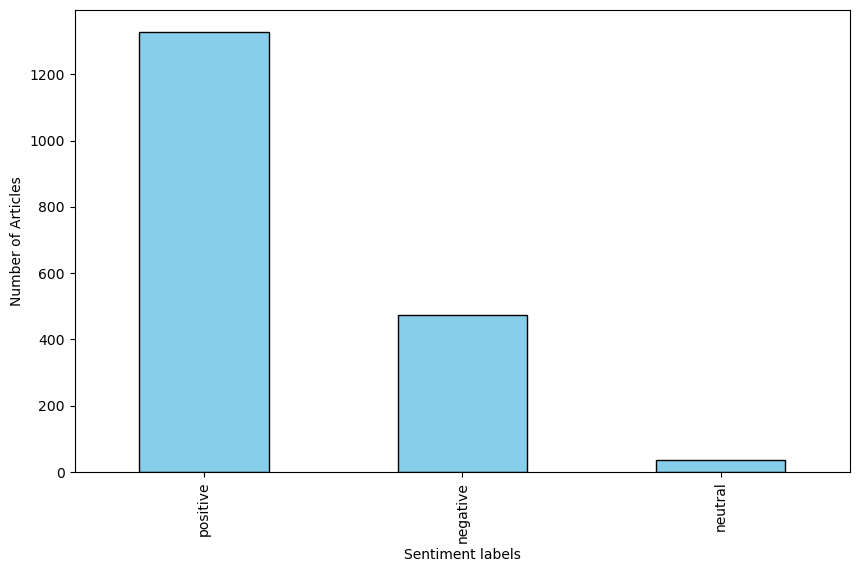

In [28]:
def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

import matplotlib.pyplot as plt
df['sentiment_label'] = df['sentiment'].apply(label_sentiment)

sentiment_counts = df['sentiment_label'].value_counts()

plt.figure(figsize=(10, 6))
sentiment_counts.plot(kind='bar', color="skyblue", edgecolor="black")
plt.xlabel("Sentiment labels")
plt.ylabel("Number of Articles")
plt.show()

<h2></h2>